# Visualization

## 1. View(3D)

In [2]:
from ase.visualize import view
from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor

structure = Structure.from_file("./AlN/tnlo_1o_HIST.nc")
atoms = AseAtomsAdaptor.get_atoms(structure)
view(atoms)

NetcdfReaderError: In file /home/mson/Documents/RESEARCH/EO/AlN/tnlo_1o_HIST.nc:
Error while reading variables: ('primitive_vectors',) with kwargs={'path': '/'}.

In [10]:
from ase.visualize import view
from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor
directory_to_file="./AlN/Sc37_5.cif"

structure = Structure.from_file(directory_to_file)
lat_a=structure.lattice.b/2
lat_c=(structure.lattice.c)/2
print(f"{directory_to_file} a: {lat_a}, c: {lat_c}")

./AlN/Sc37_5.cif a: 3.102962357969304, c: 4.957407196863557


In [8]:
structure.lattice.b/2

3.102962357969304

In [9]:
6.25718/2

3.12859

In [47]:
import numpy as np
from ase.visualize import view
from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor

structure = Structure.from_file("./AlN/Sc62_5.cif")

def average_dist(structure, index_pair, label=False):
    """
    Averaged distances between atoms of index i, j in index_pair (label=False)
    or averaged distances between atoms of label_i, label_j (e.g. 'N1','N2') in index_pair (label=True)
    """
    average_dist=0
    if label:
        for label_i,label_j in index_pair:
            structure0=structure
            for i in structure0:
                if i.label not in label_i,label_j:
                    structure0.remove[i]
            average_dist+=np.linalg.norm(structure_ij[1]-structure_ij[0])
        return average_dist/len(index_pair)     
    else:
        for i,j in index_pair:
            average_dist+=structure.get_distance(i,j)
        return average_dist/len(index_pair)

a_lat=average_dist(structure, [[16,17]], label=False)
print(a_lat)
a_lat=average_dist(structure, [['N1','N2']], label=True)
print(a_lat)

4.237221147197584
4.347657565071138


## 2. Plot Atoms

<Axes: >

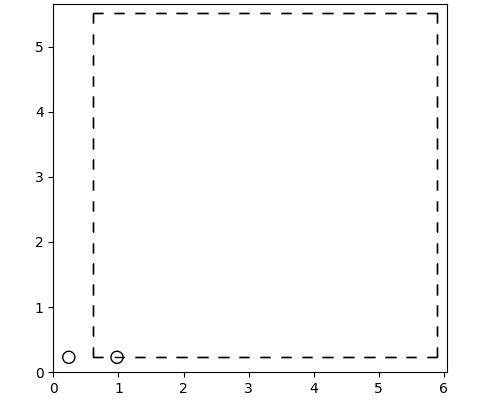

In [16]:
from ase.visualize.plot import plot_atoms
from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor

fig,ax = plt.subplots(1,1,figsize=(5,4), constrained_layout=True)
structure = Structure.from_file("/path/to/your_GSR.nc")
atoms = AseAtomsAdaptor.get_atoms(structure)
plot_atoms(atoms, ax, radii=0.3, rotation=('270x,0y,0z'))

# 3. Write a file

In [3]:
from abipy import abilab

In [1]:
from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor
from ase.io import write
structure = Structure.from_file("./AlN/AlN10_1o_GSR.nc")
atoms=AseAtomsAdaptor.get_atoms(structure)
atoms.write('aln10_1O.cif')

In [5]:
gsr = abilab.abiopen("./AlN/AlN10_1o_GSR.nc")
gsr.structure

Structure Summary
Lattice
    abc : 6.257176004243272 10.837748007349905 5.0169550034016135
 angles : 90.0 90.0 90.0
 volume : 340.2182653175647
      A : 6.257176004243272 0.0 0.0
      B : 0.0 10.837748007349905 0.0
      C : 0.0 0.0 5.0169550034016135
    pbc : True True True
PeriodicSite: Al (1.564, 0.9031, 5.013) [0.25, 0.08333, 0.9993]
PeriodicSite: Al (5.214, 0.9031, 5.013) [0.8333, 0.08333, 0.9993]
PeriodicSite: Al (6.257, 9.031, 5.013) [1.0, 0.8333, 0.9993]
PeriodicSite: Al (4.693, 9.935, 2.505) [0.75, 0.9167, 0.4993]
PeriodicSite: Al (1.564, 9.935, 2.505) [0.25, 0.9167, 0.4993]
PeriodicSite: Al (0.5214, 1.806, 2.505) [0.08333, 0.1667, 0.4993]
PeriodicSite: Al (4.693, 0.9031, 5.013) [0.75, 0.08333, 0.9993]
PeriodicSite: Al (0.5214, 9.031, 5.013) [0.08333, 0.8333, 0.9993]
PeriodicSite: Al (5.214, 9.935, 2.505) [0.8333, 0.9167, 0.4993]
PeriodicSite: Al (6.257, 1.806, 2.505) [1.0, 0.1667, 0.4993]
PeriodicSite: Al (4.693, 6.322, 5.013) [0.75, 0.5833, 0.9993]
PeriodicSite: Al (3.12

In [4]:
from ase.visualize import view
from pymatgen.core import Structure, Element
from pymatgen.io.ase import AseAtomsAdaptor 

for j in ['Fe','Zn',#...]:
    structure = Structure.from_file("./AlN13_relaxed.cif")
    for i in range(7):
        structure[i]=Element(j)
        atoms=AseAtomsAdaptor.get_atoms(structure)
        atoms.write(f'AlN{j}_input.cif')

Structure Summary
Lattice
    abc : 5.332786370564753 6.037064725841258 9.810017029455132
 angles : 90.0 90.0 90.0
 volume : 315.82738160176996
      A : 5.332786370564753 0.0 3.2653898796243777e-16
      B : 9.7083405231892e-16 6.037064725841258 3.6966359963734454e-16
      C : 0.0 0.0 9.810017029455132
    pbc : True True True
PeriodicSite: Al1 (Fe) (4.447, 1.509, 4.902) [0.8339, 0.25, 0.4997]
PeriodicSite: Al2 (Fe) (4.447, 1.509, 9.807) [0.8339, 0.25, 0.9997]
PeriodicSite: Al3 (Fe) (4.447, 4.528, 4.902) [0.8339, 0.75, 0.4997]
PeriodicSite: Al4 (Fe) (4.447, 4.528, 9.807) [0.8339, 0.75, 0.9997]
PeriodicSite: Al5 (Fe) (1.781, 0.0, 4.902) [0.3339, 0.0, 0.4997]
PeriodicSite: Al6 (Fe) (1.781, 0.0, 9.807) [0.3339, 0.0, 0.9997]
PeriodicSite: Al7 (Fe) (1.781, 3.019, 4.902) [0.3339, 0.5, 0.4997]
PeriodicSite: Al8 (Al) (1.781, 3.019, 9.807) [0.3339, 0.5, 0.9997]
PeriodicSite: Al9 (Al) (0.8855, 1.509, 2.45) [0.1661, 0.25, 0.2497]
PeriodicSite: Al10 (Al) (0.8855, 1.509, 7.355) [0.1661, 0.25, 0.7